# Part A: Analyze the results of your checkpoint study

## Step 1A: Take Your Study and Analyze the Results

Get 2 "participants" to take your study and collect their data.  If you're working in a pair, you can take it once each.  If you're working alone, you can do twice yourself, or do it once and ask a friend to do it once.  

Download your data from qualtrics, and read it into this notebook to analyze it.  

You will want to keep track of the following (at minimum) for each trial:
- The time to complete the trial
- Whether the trial was correctly completed
- Which condition the trial belongs to
- Which participant the trial was completed by

This data was imported from Qaultrics and cleaned manually. Here is a link to the data sheet: https://docs.google.com/spreadsheets/d/1dc44_Wpj2510XBndS_58BoAHyUev6rSK5BjtkBSjILE/edit?gid=1294774944#gid=1294774944

## Step 2A: Display summary statistics for your trial data

1. Make a histogram of response times for each condition

2. Print the mean response time for each condition

3. Print the mean response time for each participant

4. Print the average number of correct responses for each condition

5. Print the average number of correct responses for each participant

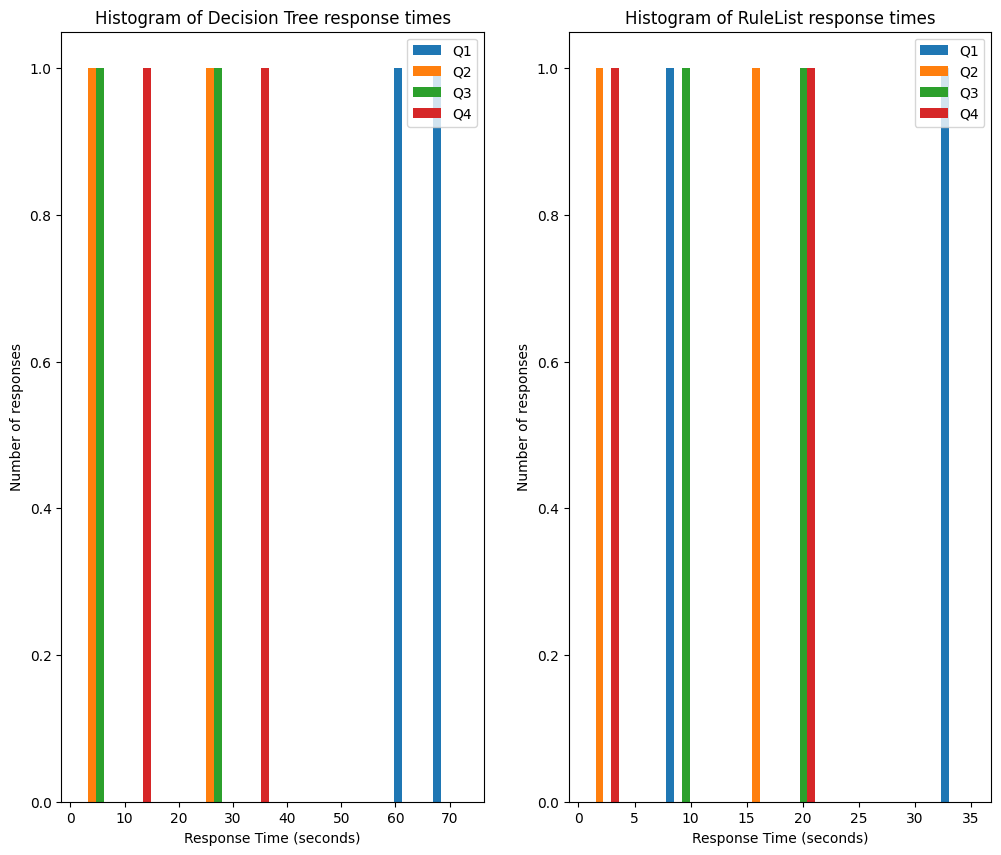

Mean response times for Decision Tree: 29.667375000000003
Mean response times for Rulelist: 14.246125000000001
Mean response time for each particiapnt:
     mean_DT   mean_RL
0  40.17050  22.71450
1  19.16425   5.77775
Avg number of correct responses for the Decision Tree: 4.0
Avg number of correct responses for the Rulelist: 3.5
0    8
1    7
Name: Total, dtype: object
Avg number of correct responses for each participant:
   Participant_correct
0                 1.0
1               0.875


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data= pd.read_csv('SurveyData.csv')
df= pd.DataFrame(data)


plt.figure(figsize=(12, 10))

#Decision Tree Plot
plt.subplot(1, 2, 1)
plt.hist([df['Timing A1'], df['Timing A2'], df['Timing A3'], df['Timing A4']], bins=10, label=['Q1', 'Q2', 'Q3', 'Q4'])
plt.title('Histogram of Decision Tree response times')
plt.xlabel('Response Time (seconds)')
plt.ylabel('Number of responses')
plt.legend()

#Rulelist Plot
plt.subplot(1, 2, 2)
plt.hist([df['Timing B1'], df['Timing B2'], df['Timing B3'], df['Timing B4']], bins=10, label=['Q1', 'Q2', 'Q3', 'Q4'])
plt.title('Histogram of RuleList response times')
plt.xlabel('Response Time (seconds)')
plt.ylabel('Number of responses')
plt.legend()

plt.show()


# I'm not sure if the condition refers to each trial/instance or each model. I have presented data for the latter case, however if you meant the former then just remove the second ".mean()" for the next two statistics.
mean_DT= df[['Timing A1', 'Timing A2', 'Timing A3', 'Timing A4']].mean().mean()
print('Mean response times for Decision Tree:', mean_DT)
mean_RL= df[['Timing B1', 'Timing B2', 'Timing B3', 'Timing B4']].mean().mean()
print('Mean response times for Rulelist:', mean_RL)


df['mean_DT']= df[['Timing A1', 'Timing A2', 'Timing A3', 'Timing A4']].mean(axis=1)
df['mean_RL']= df[['Timing B1', 'Timing B2', 'Timing B3', 'Timing B4']].mean(axis=1)
print('Mean response time for each particiapnt:\n', df[['mean_DT', 'mean_RL']])

DT_correct= df[['Q1','Q2','Q3', 'Q4']].sum(axis=1)
DT_correct+= (df[['Q1','Q2','Q3', 'Q4']]== False).sum(axis=1)
RL_correct= df[['Q5','Q6','Q7', 'Q8']].sum(axis=1)
RL_correct+= (df[['Q1','Q2','Q3', 'Q4']]== False).sum(axis=1)
print('Avg number of correct responses for the Decision Tree:', DT_correct.mean())
print('Avg number of correct responses for the Rulelist:', RL_correct.mean()) 

df['Total']= DT_correct + RL_correct 
print(df['Total'])# should be a total of 15. 8 for participant 0 and 7 of participant 1

df['Participant_correct']= df['Total']/8 

print('Avg number of correct responses for each participant:\n', df[['Participant_correct']])





## Step 3A: Compute statistical tests

1. Compute an independent-samples t-test comparing the response times of the 2 conditions
2. Compute a paired-samples t-test comparing the response times of the 2 conditions

You are unlikely to see a statistical difference with the amount of data you have collected.

In [9]:
from scipy.stats import ttest_ind, ttest_rel


DT_times = df[['Timing A1', 'Timing A2', 'Timing A3', 'Timing A4']].mean(axis=1)  
RL_times = df[['Timing B1', 'Timing B2', 'Timing B3', 'Timing B4']].mean(axis=1) 

ind_t_stat, ind_p_val = ttest_ind(DT_times, RL_times)  
print("Independent-samples t-test:")
print('t-statistic and p-value: ', ind_t_stat,',' , ind_p_val)

if ind_p_val > 0.05:
    print("This test shows no statisical significance")
else:
    print("This test shows a statistical difference")

paired_t_stat, paired_p_val = ttest_rel(DT_times, RL_times)
print('Paired-samples t-test:',)
print('t-statistic and p-value:', paired_t_stat, ',' , paired_p_val)

if paired_p_val > 0.05:
    print("This test shows no statisical significance")
else:
    print("This test shows a statistical difference")


Independent-samples t-test:
t-statistic and p-value:  1.1430080111537366 , 0.3714104491288992
This test shows no statisical significance
Paired-samples t-test:
t-statistic and p-value: 7.57894090183069 , 0.08351608951338989
This test shows no statisical significance


### Writing prompt 1: Model comparison

Based on your study results, which of the 2 models is more interpretable?  (1-3 sentences).  

The results are not statistically significant so we will omit our test statistics in our response to this question. Looking at Step 2A, one can observe that it takes less time to complete the Rulelist but that responses for the Decision Tree are more accurate. Our metric for interpretability is how fast it takes a participant to make accurate predictions using a given model. Since these metrics are not in agreeance, we looked at the percent difference for accuracy and time. It showed a large discrepancy between our mean response times which leads us to focus on response time a the deciding factor for interpreatbility in this context. The lower mean response time was for the RuleList so we claim that the RuleList is more interpretable.

### Writing prompt 2: Study limitations

What limitations of your study would you change to make your results more valid and generalizable?  Please list at least 2 limitations and describe why they are limitations (1-2 sentences each).   

There were few limitations in this study but the two that we would like to focus on are: 
1. Response validation
2. Sample size

We consider these to be limitations because a sample size of 2 almost never yields a statisically significant result because the statisical power is too low and there may be random variability in the data (we want to protect against this). Without a large sample size, it is hard to generalize findings because the data won't fit any particular distribution were we could make claims about particular data points or groups of data. This also amplifies our first issue, response validation. Because we didn't ensure that every participant answered all of the questions we have varying amounts of data between our samples, this has made it difficult to ensure that we can draw meaningful conclusions as our incomplete data may skew results. To improve both of these we would include a sample size to affect a reasonable statisical power and require that all participants answer all questions before the survey can be completed.

# Part B: Designing Your Own Study

In the study_inputs zip folder, you will find 6 decision set models corresponding to 3 different conditions.  Each model is a decision set, which is very similar to a rule list.  Please read the study_input_instructions.pdf in the study_inputs folder to better understand how these models can be used to make predictions.  

Your goal in this part of the project is to design an interpretability experiment around these inputs, and to implement it as a Qualtrics study.  Your study should use a simulation task--i.e. asking participants to determine the prediction made by the model on a specified instance.  You do not need to collect and analyze data for this, but you will implement your study in qualtrics, and describe your design choices in a written report.  **You can find a study design template document in the assignment with an outline based on the requirements listed below.**

### Step 1B: Define your research question
Frame your study around a specific research question and articulate it clearly in the Research Question section of your report.  This should be 1-2 paragraphs and should describe the high-level goal of your study.   

### Step 2B: Make your design choices:
Make and justify the following design choices in the Design Choices section of your report.  Each design choice should be approximately a paragraph and should clearly describe what the design choice is, why you made it, and how it contributes to answering your research question.

1. **What primary metric do you plan to analyze for your study?**  You do not need to collect data and analyze data using this survey, but you should implement the survey in such a way that you could collect the necessary data to analyze your metric.  For example, if you plan to analyze response time, I expect to see your study collecting response time for each trial.  Other metrics you may consider include how accurately participants can determine the prediction made by the model, and user satisfaction with the explanation.  Please include a screenshot of one of your trials in this section to show how you will collect the data needed to compute your metric.

2. **Which instances will you use in your trials?**  You should hand-select instances by generating a specific set of feature values.  Use each instance in a Qualtrics trial for a different model (6 total).  You should describe the considerations you made when generating these instances.  For example, consider how we carefully chose instances in the checkpoint notebook by balancing the number of positive and negative predictions, and making sure that they had a statistically decision average path length.  Make sure to justify these considerations.  Please include screenshots of at least 2 trials and use them  describe the key considerations for the instances.

3. **Will your study be a within-subjects or a between-subject study?**  I.e. will every participant complete all 3 conditions, two conditions, or just one condition?  Why did you make that choice?  Consider tradeoffs such as the total amount of participants needed, the length of the study, whether participants will get tired or learn to do the task too well over multiple conditions.

4. **How will you handle randomizing your trials?** Will you do block-randomization all of the trials for each condition are contiguous, but the order of trials differs?  Will you fully randomize the order of the 6 trials?  Will you do no randomization at all?  Consider tradeoffs such as whether

### Step 3B: Make your design choices: Implement your study
Implement your study in Qualtrics.  A complete implementation will have 6 trials, each with one of the 6 provided models and an instance generated by you.  The study implementation should correspond to the design choices you listed above.  For example, if you say half of your instances are positive and half are negative, that should be true in your study.  If you say that you will measure user satisfaction as your primary metric, you should include a question asking about user satisfaction for each trial.

**Include the study link here:**


https://qualtricsxmhyg56fskv.qualtrics.com/jfe/form/SV_6FGfpOF4e5tjOYe